# Example running RMG with a thermo lib with coverage-dependence

In [1]:
import os
import numpy as np
import subprocess
import cantera as ct
import matplotlib.pyplot as plt
%matplotlib inline


# Run baseline and coverage-dependent RMG jobs

Each of the runs should take less than 2 minutes

In [2]:
base_rmg_run_dir = os.path.join('temp', 'base_rmg_run')
cov_dep_rmg_run_dir = os.path.join('temp', 'cov_dep_rmg_run')
os.makedirs(base_rmg_run_dir, exist_ok=True)
os.makedirs(cov_dep_rmg_run_dir, exist_ok=True)

input_file = """
# Data sources
database(
    thermoLibraries=['surfaceThermoCovDepPt111', 'surfaceThermoPt111', 'primaryThermoLibrary', 'thermo_DFT_CCSDTF12_BAC','DFT_QCI_thermo'],
    reactionLibraries = [
    ('Surface/Methane/Deutschmann_Pt', False),
    ('Surface/Methane/Vlachos_Pt111', False),
    'BurkeH2O2inArHe'],
    seedMechanisms = [],
    kineticsDepositories = ['training'],
    kineticsFamilies =['surface','default'],
    kineticsEstimator = 'rate rules',
)

catalystProperties( # default values for Pt(111)
    metal = 'Pt111',
    thermoCoverageDependence = False,
)

# List of species
species(
    label='X',
    reactive=True,
    structure=adjacencyList("1 X u0"),
)

species(
    label='CH4',
    reactive=True,
    structure=SMILES("[CH4]"),
)
species(
    label='O2',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u1 p2 c0 {2,S}
    2 O u1 p2 c0 {1,S}
    '''),
)

species(
    label='Ar',
    reactive=False,
    structure=SMILES("[Ar]"),
)

species(
    label='CO2',
    reactive=True,
    structure=SMILES("O=C=O"),
)

species(
    label='H2O',
    reactive=True,
    structure=SMILES("O"),
)

species(
    label='H2',
    reactive=True,
    structure=SMILES("[H][H]"),
)

species(
    label='CO',
    reactive=True,
    structure=SMILES("[C-]#[O+]"),
)

species(
    label='C2H6',
    reactive=True,
    structure=SMILES("CC"),
)

species(
    label='CH2O',
    reactive=True,
    structure=SMILES("C=O"),
)

species(
    label='CH3',
    reactive=True,
    structure=SMILES("[CH3]"),
)

species(
    label='C3H8',
    reactive=True,
    structure=SMILES("CCC"),
)

species(
    label='H',
    reactive=True,
    structure=SMILES("[H]"),
)

species(
    label='C2H5',
    reactive=True,
    structure=SMILES("C[CH2]"),
)

species(
    label='CH3OH',
    reactive=True,
    structure=SMILES("CO"),
)

species(
    label='HCO',
    reactive=True,
    structure=SMILES("[CH]=O"),
)

species(
    label='CH3CHO',
    reactive=True,
    structure=SMILES("CC=O"),
)

species(
    label='OH',
    reactive=True,
    structure=SMILES("[OH]"),
)

species(
    label='C2H4',
    reactive=True,
    structure=SMILES("C=C"),
)

species(
    label='CH3CH',
    reactive=True,
    structure=SMILES("[CH]C"),
)

species(
    label='CH3OO',
    reactive=True,
    structure=SMILES("CO[O]"),
)

species(
    label='HX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 H u0 p0 c0 {2,S}
    2 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='CO2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {3,D}
    2 O u0 p2 c0 {3,D}
    3 C u0 p0 c0 {1,D} {2,D}
    4 X u0 p0 c0
    '''),
)

species(
    label='COX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 C u0 p0 c0 {1,D} {3,D}
    3 X u0 p0 c0 {2,D}
    '''),
)

species(
    label='CH4X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 H u0 p0 c0 {1,S}
    5 H u0 p0 c0 {1,S}
    6 X u0 p0 c0
    '''),
)

species(
    label='OX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 X u0 p0 c0 {1,D}
    '''),
)

species(
    label='CH2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,D}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 X u0 p0 c0 {1,D}
    '''),
)

species(
    label='CH3X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 H u0 p0 c0 {1,S}
    5 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='CHX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,S} {3,T}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0 {1,T}
    '''),
)

species(
    label='CX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 C u0 p0 c0 {2,Q}
    2 X u0 p0 c0 {1,Q}
    '''),
)

species(
    label='H2X',
    reactive=True,
    structure=adjacencyList(
    '''
    1 H u0 p0 c0 {2,S}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0
    '''),
)

species(
    label='OHX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,S} {3,S}
    2 H u0 p0 c0 {1,S}
    3 X u0 p0 c0 {1,S}
    '''),
)

species(
    label='H2OX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,S} {3,S}
    2 H u0 p0 c0 {1,S}
    3 H u0 p0 c0 {1,S}
    4 X u0 p0 c0
    '''),
)

species(
    label='CHOX',
    reactive=True,
    structure=adjacencyList(
    '''
    1 O u0 p2 c0 {2,D}
    2 C u0 p0 c0 {1,D} {3,S} {4,S}
    3 H u0 p0 c0 {2,S}
    4 X u0 p0 c0 {2,S}
    '''),
)

surfaceReactor(
    temperature=(1000,'K'),
    initialPressure=(1.0, 'bar'),
    initialGasMoleFractions={
        "CH4": 0.041866,
        "O2": 0.03488,
        "Ar": 0.131246,
    },
    initialSurfaceCoverages={
        "X": 1.0,
    },
    surfaceVolumeRatio=(1.e5, 'm^-1'),
    terminationConversion = { "CH4":0.95,},
    terminationTime=(10., 's'),
    # terminationConversion={'O2': 0.99,},
    terminationRateRatio=0.05
)


simulator(
    atol=1e-18,
    rtol=1e-12,
)

model(
    toleranceKeepInEdge=0.0,
    toleranceMoveToCore=1e-1,
    toleranceInterruptSimulation=1e8,
    maximumEdgeSpecies=500000,
    maxNumSpecies=40,
)

options(
    units='si',
    saveRestartPeriod=None,
    generateOutputHTML=True,
    generatePlots=False,
    saveEdgeSpecies=True,
    saveSimulationProfiles=True,
)

generatedSpeciesConstraints(
    allowed=['input species','reaction libraries'],
    maximumSurfaceSites=1,
)
"""

rmgpy_path = '../rmg.py' # Change to your rmg.py path


input_path = os.path.join(base_rmg_run_dir, 'input.py')
with open(input_path,'w') as f:
    f.write(input_file)
print(f"Running RMG with input file at {input_path}...")
subprocess.check_call(['python', rmgpy_path, input_path])


# repeat for coverage dependent run
input_path = os.path.join(cov_dep_rmg_run_dir, 'input.py')
input_file = input_file.replace('thermoCoverageDependence = False', 'thermoCoverageDependence = True')
with open(input_path,'w') as f:
    f.write(input_file)
print(f"Running RMG with input file at {input_path}...")
subprocess.check_call(['python', rmgpy_path, input_path])

Running RMG with input file at temp/base_rmg_run/input.py...


:root:Removing old /home/moon/rmg/RMG-Py/ipython/temp/base_rmg_run/RMG_backup.log
:root:Moving /home/moon/rmg/RMG-Py/ipython/temp/base_rmg_run/RMG.log to /home/moon/rmg/RMG-Py/ipython/temp/base_rmg_run/RMG_backup.log



Global RMG Settings:
   database.directory   = /home/moon/rmg/RMG-database/input (Default, relative to RMG-Py source code)
   test_data.directory  = /home/moon/rmg/RMG-Py/test/rmgpy/test_data (Default, relative to RMG-Py source code)
RMG execution initiated at Thu Apr 16 08:23:40 2026

#########################################################
# RMG-Py - Reaction Mechanism Generator in Python       #
# Version: 3.3.0                                        #
# Authors: RMG Developers (rmg_dev@mit.edu)             #
# P.I.s:   William H. Green (whgreen@mit.edu)           #
#          Richard H. West (r.west@neu.edu)             #
# Website: http://reactionmechanismgenerator.github.io/ #
#########################################################

The current git HEAD for RMG-Py is:
	b'40e65623c140cfd4ec877b939c23163cde07622e'
	b'Fri Apr 10 09:36:20 2026 -0400'

The current git HEAD for RMG-database is:
	b'd772ee69457449709fd0ec02a1da3e7732944f84'
	b'Thu Apr 16 08:21:16 2026 -0400'

Reading 

Loading transport library from GRI-Mech.py in /home/moon/rmg/RMG-database/input/transport/libraries...
Loading transport library from NIST_Fluorine.py in /home/moon/rmg/RMG-database/input/transport/libraries...
Loading transport group database from /home/moon/rmg/RMG-database/input/transport/groups...


Loading kinetics library Surface/Methane/Deutschmann_Pt from /home/moon/rmg/RMG-database/input/kinetics/libraries/Surface/Methane/Deutschmann_Pt/reactions.py...
Loading kinetics library Surface/Methane/Vlachos_Pt111 from /home/moon/rmg/RMG-database/input/kinetics/libraries/Surface/Methane/Vlachos_Pt111/reactions.py...
Loading kinetics library BurkeH2O2inArHe from /home/moon/rmg/RMG-database/input/kinetics/libraries/BurkeH2O2inArHe/reactions.py...
Loading frequencies group database from /home/moon/rmg/RMG-database/input/statmech/groups...


...



For reaction generation 1 process is used.

Summary of Secondary Model Edge Enlargement
---------------------------------
Added 0 new core species
Created 0 new edge species
Added 0 new core reactions
Created 0 new edge reactions

After model enlargement:
    The model core has 39 species and 148 reactions
    The model edge has 249 species and 698 reactions


Saving current model core to Chemkin file...
Chemkin file contains 46 reactions.
Chemkin file contains 102 reactions.
Saving annotated version of Chemkin files...
Chemkin file contains 46 reactions.
Chemkin file contains 102 reactions.
Saving current model core and edge to Chemkin file...
Chemkin file contains 545 reactions.
Chemkin file contains 304 reactions.
Saving annotated version of Chemkin files...
Chemkin file contains 545 reactions.
Chemkin file contains 304 reactions.
Saving current model core to HTML file...


Saving current model edge to HTML file...


Updating RMG execution statistics...
    Execution time (DD:HH:MM:SS): 00:00:01:48
    Memory used: 890.50 MB

Making seed mechanism...


Performing final model checks...
No collision rate violators found in the model's core.

MODEL GENERATION COMPLETED

The final model core has 39 species and 148 reactions
The final model edge has 249 species and 698 reactions

RMG execution terminated at Thu Apr 16 08:26:21 2026


0

# Simulate the RMG mechanisms

In [3]:
# Load mechanism
base_mech_yaml = os.path.join(base_rmg_run_dir, 'cantera', 'chem_annotated.yaml')
gas_base = ct.Solution(base_mech_yaml)
surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
print(f'Base mechanism contains {gas_base.n_species} gas species and {surf_base.n_species} surface species')


cov_dep_mech_yaml = os.path.join(cov_dep_rmg_run_dir, 'cantera', 'chem_annotated.yaml')
gas_cov_dep = ct.Solution(cov_dep_mech_yaml)
surf_cov_dep = ct.Interface(cov_dep_mech_yaml, 'SURF0', [gas_cov_dep])
print(f'Coverage-dependent mechanism contains {gas_cov_dep.n_species} gas species and {surf_cov_dep.n_species} surface species')

def get_i_thing(ref_composition, phase):
	for i in range(phase.n_species):
		if phase.species()[i].composition == ref_composition:
			return i
	return -1


# simulate
# Set initial conditions
T = 1000.0  # K
P = 100000.0  # Pa
i_CO_base = get_i_thing({'C': 1, 'O': 1}, gas_base)
i_H2_base = get_i_thing({'H': 2}, gas_base)

initial_mole_fractions = f'{gas_base.species_names[i_CO_base]}: 0.5, {gas_base.species_names[i_H2_base]}: 0.5'
initial_surface_coverages = 'X(1): 1.0'


gas_base.TPX = T, P, initial_mole_fractions
gas_reactor = ct.IdealGasReactor(gas_base, energy='off')  # energy off makes it isothermal

surf_base.TP = T, P                
surf_base.coverages = initial_surface_coverages
surf_reactor = ct.ReactorSurface(surf_base, gas_reactor)

net = ct.ReactorNet([gas_reactor])

times_base = [net.time]
gas_concentrations_base = [gas_base.X]
surf_concentrations_base = [surf_base.coverages]

termination_time = 1.0  # s
while net.time < termination_time:
    net.step()
    times_base.append(net.time)
    gas_concentrations_base.append(gas_base.X)
    surf_concentrations_base.append(surf_base.coverages)

times_base = np.array(times_base)
gas_concentrations_base = np.array(gas_concentrations_base)
surf_concentrations_base = np.array(surf_concentrations_base)


# --------------------- Run coverage-dependent simulation ---------------------
i_CO_cov_dep = get_i_thing({'C': 1, 'O': 1}, gas_cov_dep)
i_H2_cov_dep = get_i_thing({'H': 2}, gas_cov_dep)

initial_mole_fractions = f'{gas_cov_dep.species_names[i_CO_cov_dep]}: 0.5, {gas_cov_dep.species_names[i_H2_cov_dep]}: 0.5'
initial_surface_coverages = 'X(1): 1.0'


gas_cov_dep.TPX = T, P, initial_mole_fractions
gas_reactor = ct.IdealGasReactor(gas_cov_dep, energy='off')  # energy off makes it isothermal

surf_cov_dep.TP = T, P                
surf_cov_dep.coverages = initial_surface_coverages
surf_reactor = ct.ReactorSurface(surf_cov_dep, gas_reactor)

net = ct.ReactorNet([gas_reactor])

times_cov_dep = [net.time]
gas_concentrations_cov_dep = [gas_cov_dep.X]
surf_concentrations_cov_dep = [surf_cov_dep.coverages]

termination_time = 1.0  # s
while net.time < termination_time:
    net.step()
    times_cov_dep.append(net.time)
    gas_concentrations_cov_dep.append(gas_cov_dep.X)
    surf_concentrations_cov_dep.append(surf_cov_dep.coverages)

times_cov_dep = np.array(times_cov_dep)
gas_concentrations_cov_dep = np.array(gas_concentrations_cov_dep)
surf_concentrations_cov_dep = np.array(surf_concentrations_cov_dep)


Base mechanism contains 22 gas species and 17 surface species
Coverage-dependent mechanism contains 22 gas species and 17 surface species


/tmp/ipykernel_663369/4041569244.py:4: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'H(12) + X(1) <=> HX(21)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
/tmp/ipykernel_663369/4041569244.py:4: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'OH(17) + X(1) <=> OHX(31)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_base = ct.Interface(base_mech_yaml, 'SURF0', [gas_base])
/tmp/ipykernel_663369/4041569244.py:10: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'H(12) + X(1) <=> HX(21)'
at T = 200.0
at T = 500.0
at T = 1000.0
at T = 2000.0
at T = 5000.0
at T = 10000.0

  surf_cov_dep = ct.Interface(cov_dep_mech_yaml, 'SURF0', [gas_cov_dep])
/tmp/ipykernel_663369/4041569244.py:10: UserWarning: StickingRate::validate: 
S

# Coverage-dependent thermo results in less CO on the surface

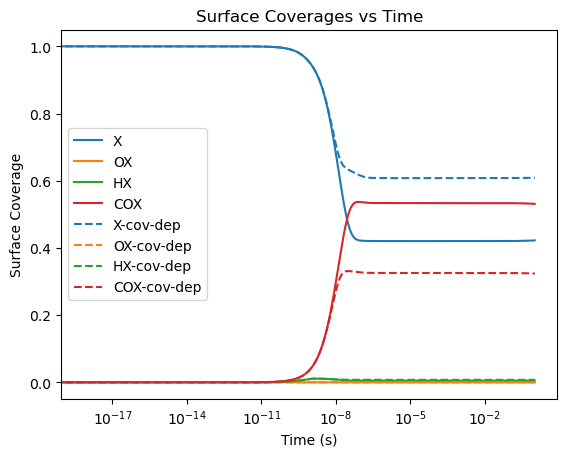

In [4]:
# Plot the results
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot COX, X, OX, HX
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'X': 1}, surf_base)], label='X', color=colors[0])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'O': 1, 'X': 1}, surf_base)], label='OX', color=colors[1])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'H': 1, 'X': 1}, surf_base)], label='HX', color=colors[2])
plt.plot(times_base, surf_concentrations_base[:, get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_base)], label='COX', color=colors[3])

# plot cov-dep
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'X': 1}, surf_cov_dep)], label='X-cov-dep', color=colors[0], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'O': 1, 'X': 1}, surf_cov_dep)], label='OX-cov-dep', color=colors[1], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'H': 1, 'X': 1}, surf_cov_dep)], label='HX-cov-dep', color=colors[2], linestyle='dashed')
plt.plot(times_cov_dep, surf_concentrations_cov_dep[:, get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_cov_dep)], label='COX-cov-dep', color=colors[3], linestyle='dashed')


plt.xlabel('Time (s)')
plt.ylabel('Surface Coverage')
plt.title('Surface Coverages vs Time')
plt.legend()
plt.xscale('log')
plt.savefig('cross_surface_coverages.png')
plt.show()


In [5]:
# Compute the enthalpy of XCO versus coverage
i_XCO_base = get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_base)
i_XCO_cov_dep = get_i_thing({'C': 1, 'O': 1, 'X': 1}, surf_cov_dep)


coverages = np.linspace(0, 1, 10)
enthalpies_base = []
enthalpies_cov_dep = []

entropies_base = []
entropies_cov_dep = []

T = 300.0  # K
P = ct.one_atm  # Pa
for coverage in coverages:

    surf_base.TPX = T, P, f'X(1): {1.0 - coverage}, {surf_base.species_names[i_XCO_base]}: {coverage}'
    surf_cov_dep.TPX = T, P, f'X(1): {1.0 - coverage}, {surf_cov_dep.species_names[i_XCO_cov_dep]}: {coverage}'

    enthalpies_base.append(surf_base.standard_enthalpies_RT[i_XCO_base])
    enthalpies_cov_dep.append(surf_cov_dep.standard_enthalpies_RT[i_XCO_cov_dep])

    entropies_base.append(surf_base.standard_entropies_R[i_XCO_base])
    entropies_cov_dep.append(surf_cov_dep.standard_entropies_R[i_XCO_cov_dep])



# Enthalpy with coverage dependence corrections fits the DFT data pretty well

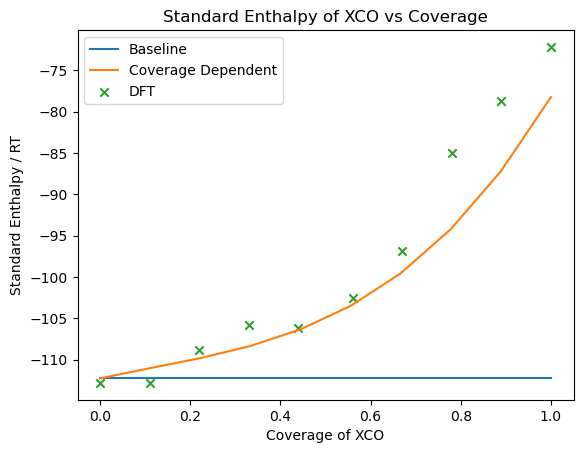

In [6]:
plt.plot(coverages, enthalpies_base, label='Baseline', color=colors[0])
plt.plot(coverages, enthalpies_cov_dep, label='Coverage Dependent', color=colors[1])

# these values copied from Cantera example: https://cantera.org/dev/examples/python/thermo/coverage_dependent_surf.html
# provide discrete enthalpy and entropy values calculated with DFT
# array of CO* coverage
dft_covs = [0., 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.0]
# array of nondimensionalized DFT-derived CO* enthalpy values
dft_hrts = [-112.8 , -112.8 , -108.78, -105.76, -106.11, -102.51,  -96.83,
            -85.03,  -78.76,  -72.19]

plt.scatter(dft_covs, dft_hrts, label='DFT', color=colors[2], marker='x')


plt.xlabel('Coverage of XCO')
plt.ylabel('Standard Enthalpy / RT')
plt.title('Standard Enthalpy of XCO vs Coverage')
plt.legend()

# Entropy with coverage dependence corrections matches the shape of DFT, but has an offset

## This is because we took the XCO coverage-dependence parameters from Bae et al., but use the more recent NASA polynomials by Kirk Badger

https://pubs.acs.org/doi/full/10.1021/acs.jcim.4c02167 - Bae et al.

See RMG-database/input/thermo/libraries/surfaceThermoCovDepPt111.py for more details

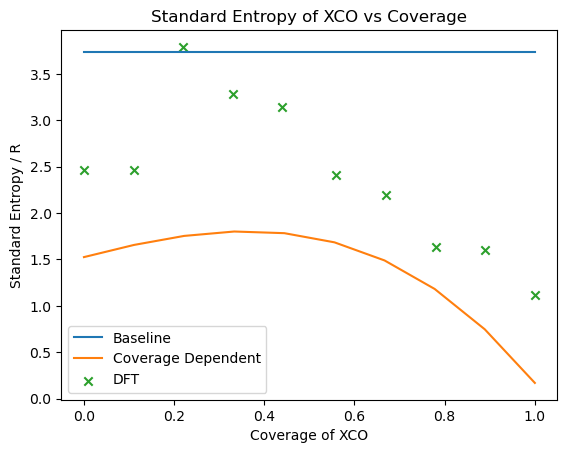

In [7]:
plt.plot(coverages, entropies_base, label='Baseline', color=colors[0])
plt.plot(coverages, entropies_cov_dep, label='Coverage Dependent', color=colors[1])

# these values copied from Cantera example: https://cantera.org/dev/examples/python/thermo/coverage_dependent_surf.html
# provide discrete enthalpy and entropy values calculated with DFT
# array of CO* coverage
dft_covs = [0., 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.0]

# array of nondimensionalized DFT-derived CO* entropy values
dft_srs = [2.46, 2.46, 3.79, 3.28, 3.14, 2.41, 2.19, 1.63, 1.6 , 1.12]

plt.scatter(dft_covs, dft_srs, label='DFT', color=colors[2], marker='x')


plt.xlabel('Coverage of XCO')
plt.ylabel('Standard Entropy / R')
plt.title('Standard Entropy of XCO vs Coverage')
plt.legend()


## When you subtract the difference in entropy from the Bae and Badger thermo at the low-coverage limit, the entropy matches the DFT

### Get the entropy offset between Bae and Badger at the low-coverage limit

In [8]:
phase_bae = ct.Interface('example_data/covdepsurf.yaml', 'covdep_poly')
phase_bae.TP = 300, ct.one_atm
i_XCO_bae = get_i_thing({'Pt': 1, 'C': 1, 'O': 1}, phase_bae)
phase_bae.standard_entropies_R[i_XCO_bae]
entropy_offset = phase_bae.standard_entropies_R[i_XCO_bae] - entropies_cov_dep[0]

### After applying offset, the entropy matches the DFT

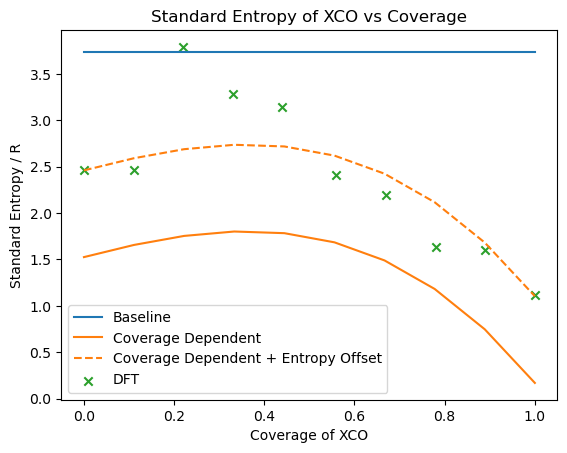

In [9]:
plt.plot(coverages, entropies_base, label='Baseline', color=colors[0])
plt.plot(coverages, entropies_cov_dep, label='Coverage Dependent', color=colors[1])
plt.plot(coverages, entropies_cov_dep + entropy_offset, label='Coverage Dependent + Entropy Offset', color=colors[1], linestyle='dashed')

# these values copied from Cantera example: https://cantera.org/dev/examples/python/thermo/coverage_dependent_surf.html
# provide discrete enthalpy and entropy values calculated with DFT
# array of CO* coverage
dft_covs = [0., 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.0]

# array of nondimensionalized DFT-derived CO* entropy values
dft_srs = [2.46, 2.46, 3.79, 3.28, 3.14, 2.41, 2.19, 1.63, 1.6 , 1.12]

plt.scatter(dft_covs, dft_srs, label='DFT', color=colors[2], marker='x')


plt.xlabel('Coverage of XCO')
plt.ylabel('Standard Entropy / R')
plt.title('Standard Entropy of XCO vs Coverage')
plt.legend()